# EE/CS 148B HW3: Colab Setup

Run the setup cells first, then each section in order. Plotting cells live directly under the experiments they analyze.

## Colab Setup

Before running:

- Switch the runtime to a GPU runtime.
- We recommend using an A100 runtime.
- Put the `hw3` directory somewhere accessible from Colab, typically Google Drive.

Note: We will be using `pip` for dependencies inside Colab.

In [1]:
%%capture
!pip -q install -U torch torchvision==2.7.1 transformers datasets "sentence-transformers<4.0" accelerate pillow tqdm matplotlib wandb pyyaml einops pytest pytest-cov pandas
!pip -q install ninja packaging
!pip -q install flash-attn --no-build-isolation
!pip install "protobuf<5" --force-reinstall

In [2]:
from pathlib import Path

USE_DRIVE = True
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/cs148b/hw3/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/hw3-sols')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
print('Using repo:', REPO_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using repo: /content/drive/MyDrive/cs148b/hw3


In [11]:
import os
import sys

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'basics'))
os.environ["PYTHONPATH"] = str(REPO_ROOT)

os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

cwd = /content/drive/.shortcut-targets-by-id/141wXwJaDiCNP1SWDcuehJctLtn7D0_46/cs148b/hw3


In [14]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from transformers import set_seed

from basics.lora import apply_lora_to_attention
from basics.text_encoder import FrozenTextEncoder
from basics.vit import ViT
from vlm.clip import ProjectionHeads
from vlm.data import EUROSAT_CLASSES, IMAGENET_MEAN, IMAGENET_STD, build_eurosat_loaders
from vlm.masking import build_causal_mask, build_image_bidir_mask

SEED = 0
set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUNS_DIR = Path('runs')
FIGURES_DIR = RUNS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def read_json(path):
    with open(path) as f:
        return json.load(f)


def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print('saved', path)


def parse_clip_log(log_path):
    rows = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(r'epoch\s+(\d+)/\d+\s+train_loss=([0-9.]+)', line)
            if m:
                rows[int(m.group(1))] = {'epoch': int(m.group(1)), 'train_loss': float(m.group(2))}
            m = re.search(r'epoch\s+(\d+)\s+val_zeroshot_acc=([0-9.]+)', line)
            if m:
                rows.setdefault(int(m.group(1)), {'epoch': int(m.group(1))})['val_zeroshot_acc'] = float(m.group(2))
    return [rows[k] for k in sorted(rows)]


def parse_clip_summary(log_path):
    summary = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(r'epoch\s+(\d+)\s+val_zeroshot_acc=([0-9.]+)', line)
            if m:
                summary['last_val_zeroshot_acc'] = float(m.group(2))
            m = re.search(
                r'pos_encoding=(\S+)\s+best_val_zeroshot_acc=([0-9.]+)\s+'
                r'test_zeroshot_acc=([0-9.]+)\s+extrap_val_zeroshot_acc=([0-9.]+)\s+'
                r'\(eval_img_size=(\d+)\)',
                line,
            )
            if m:
                summary.update(
                    {
                        'pos_encoding': m.group(1),
                        'best_val_zeroshot_acc': float(m.group(2)),
                        'test_zeroshot_acc': float(m.group(3)),
                        'extrap_val_zeroshot_acc': float(m.group(4)),
                        'eval_img_size': int(m.group(5)),
                    }
                )
    return summary


def parse_vit_profile_log(log_path):
    rows = []
    current = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(
                r'Average forward-pass time for size (\d+): ([0-9]+(?:\.[0-9]+)?)\.',
                line,
            )
            if m:
                current = {'patch_size': int(m.group(1)), 'mean_s': float(m.group(2))}
            m = re.search(
                r'Stdev of forward-pass time for size (\d+): ([0-9]+(?:\.[0-9]+)?)\.',
                line,
            )
            if m:
                current['std_s'] = float(m.group(2))
                current['mean_ms'] = current['mean_s'] * 1000
                current['std_ms'] = current['std_s'] * 1000
                current['num_patches'] = (224 // current['patch_size']) ** 2
                rows.append(current)
    return rows


def parse_vlm_log(log_path):
    train_rows, val_rows = [], []
    with open(log_path) as f:
        for line in f:
            m = re.search(r'step\s+(\d+)\s+train_loss=([0-9.]+).*peak_mem_mb=([0-9.]+)', line)
            if m:
                train_rows.append(
                    {
                        'step': int(m.group(1)),
                        'train_loss': float(m.group(2)),
                        'peak_mem_mb': float(m.group(3)),
                    }
                )
            m = re.search(r'step\s+(\d+)\s+val_acc=([0-9.]+)', line)
            if m:
                val_rows.append({'step': int(m.group(1)), 'val_acc': float(m.group(2))})
    return train_rows, val_rows


def summarize_vlm_run(run_dir):
    run_dir = Path(run_dir)
    summary = {'run_dir': str(run_dir)}
    best_path = run_dir / 'best.pt'
    log_path = run_dir / 'train.log'
    if best_path.exists():
        ckpt = torch.load(best_path, map_location='cpu', weights_only=True)
        summary.update(
            {
                'injection': ckpt.get('injection'),
                'mask_mode': ckpt.get('mask_mode'),
                'freeze_config': ckpt.get('freeze_config'),
                'best_val_acc': ckpt.get('val_metrics', {}).get('overall'),
                'step': ckpt.get('step'),
            }
        )
        vit_cfg = ckpt.get('vit_config') or ckpt.get('config', {}).get('vit', {})
        if ckpt.get('injection') == 'cls':
            summary['num_visual_tokens'] = 1
        elif vit_cfg:
            summary['num_visual_tokens'] = (vit_cfg['img_size'] // vit_cfg['patch_size']) ** 2 + 1
    if log_path.exists():
        train_rows, _ = parse_vlm_log(log_path)
        if train_rows:
            summary['peak_mem_mb'] = max(r['peak_mem_mb'] for r in train_rows)
    return summary


print('device =', DEVICE)
if torch.cuda.is_available():
    print('gpu =', torch.cuda.get_device_name(0))
print('HW3 imports and plotting helpers loaded.')

device = cuda
gpu = NVIDIA A100-SXM4-40GB
HW3 imports and plotting helpers loaded.


## 2. ViT

In [12]:
# RUNS_DIR.mkdir(parents=True, exist_ok=True)
# !python scripts/profile_vit_patch.py | tee runs/vit_patch_profile.log

Average forward-pass time for size 8: 6.512402263500007.
Stdev of forward-pass time for size 8: 0.10839465148429767.
Average forward-pass time for size 16: 0.6348834516000352.
Stdev of forward-pass time for size 16: 0.060328086777037875.
Average forward-pass time for size 32: 0.13006729044998339.
Stdev of forward-pass time for size 32: 0.0046254643572397345.


### §2.4 Patch-size benchmark plot

   patch_size  num_patches      mean_ms      std_ms
0           8          784  6512.402264  108.394651
1          16          196   634.883452   60.328087
2          32           49   130.067290    4.625464


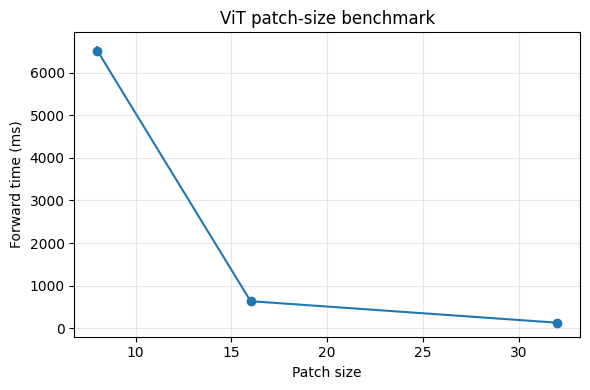

saved runs/figures/vit_patch_benchmark.png


In [15]:
log_path = RUNS_DIR / 'vit_patch_profile.log'
rows = parse_vit_profile_log(log_path)
assert rows, f'missing {log_path}'

df = pd.DataFrame(rows)
print(df[['patch_size', 'num_patches', 'mean_ms', 'std_ms']])

plt.figure(figsize=(6, 4))
plt.errorbar(df['patch_size'], df['mean_ms'], yerr=df['std_ms'], marker='o')
plt.xlabel('Patch size')
plt.ylabel('Forward time (ms)')
plt.title('ViT patch-size benchmark')
plt.grid(True, alpha=0.3)
savefig('vit_patch_benchmark.png')

## 3. CLIP Pre-training

In [ ]:
# !(mkdir -p runs/clip_eurosat && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc learned --output-dir runs/clip_eurosat | tee runs/clip_eurosat/train.log)

### §3.3 CLIP training curves

In [ ]:
# nvm did this in wandb
# history = parse_clip_log(RUNS_DIR / 'clip_eurosat' / 'train.log')
# df = pd.DataFrame(history)

# plt.figure(figsize=(6, 4))
# plt.plot(df['epoch'], df['train_loss'], marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Train loss')
# plt.title('CLIP training loss')
# plt.grid(True, alpha=0.3)
# savefig('clip_train_loss.png')

# plt.figure(figsize=(6, 4))
# plt.plot(df['epoch'], df['val_zeroshot_acc'], marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Val zero-shot accuracy')
# plt.title('CLIP zero-shot validation accuracy')
# plt.grid(True, alpha=0.3)
# savefig('clip_val_zeroshot_acc.png')

### §3.3 Zero-shot qualitative examples

5 correctly classified and 5 incorrectly classified validation images, with top-3 predictions for the mistakes.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

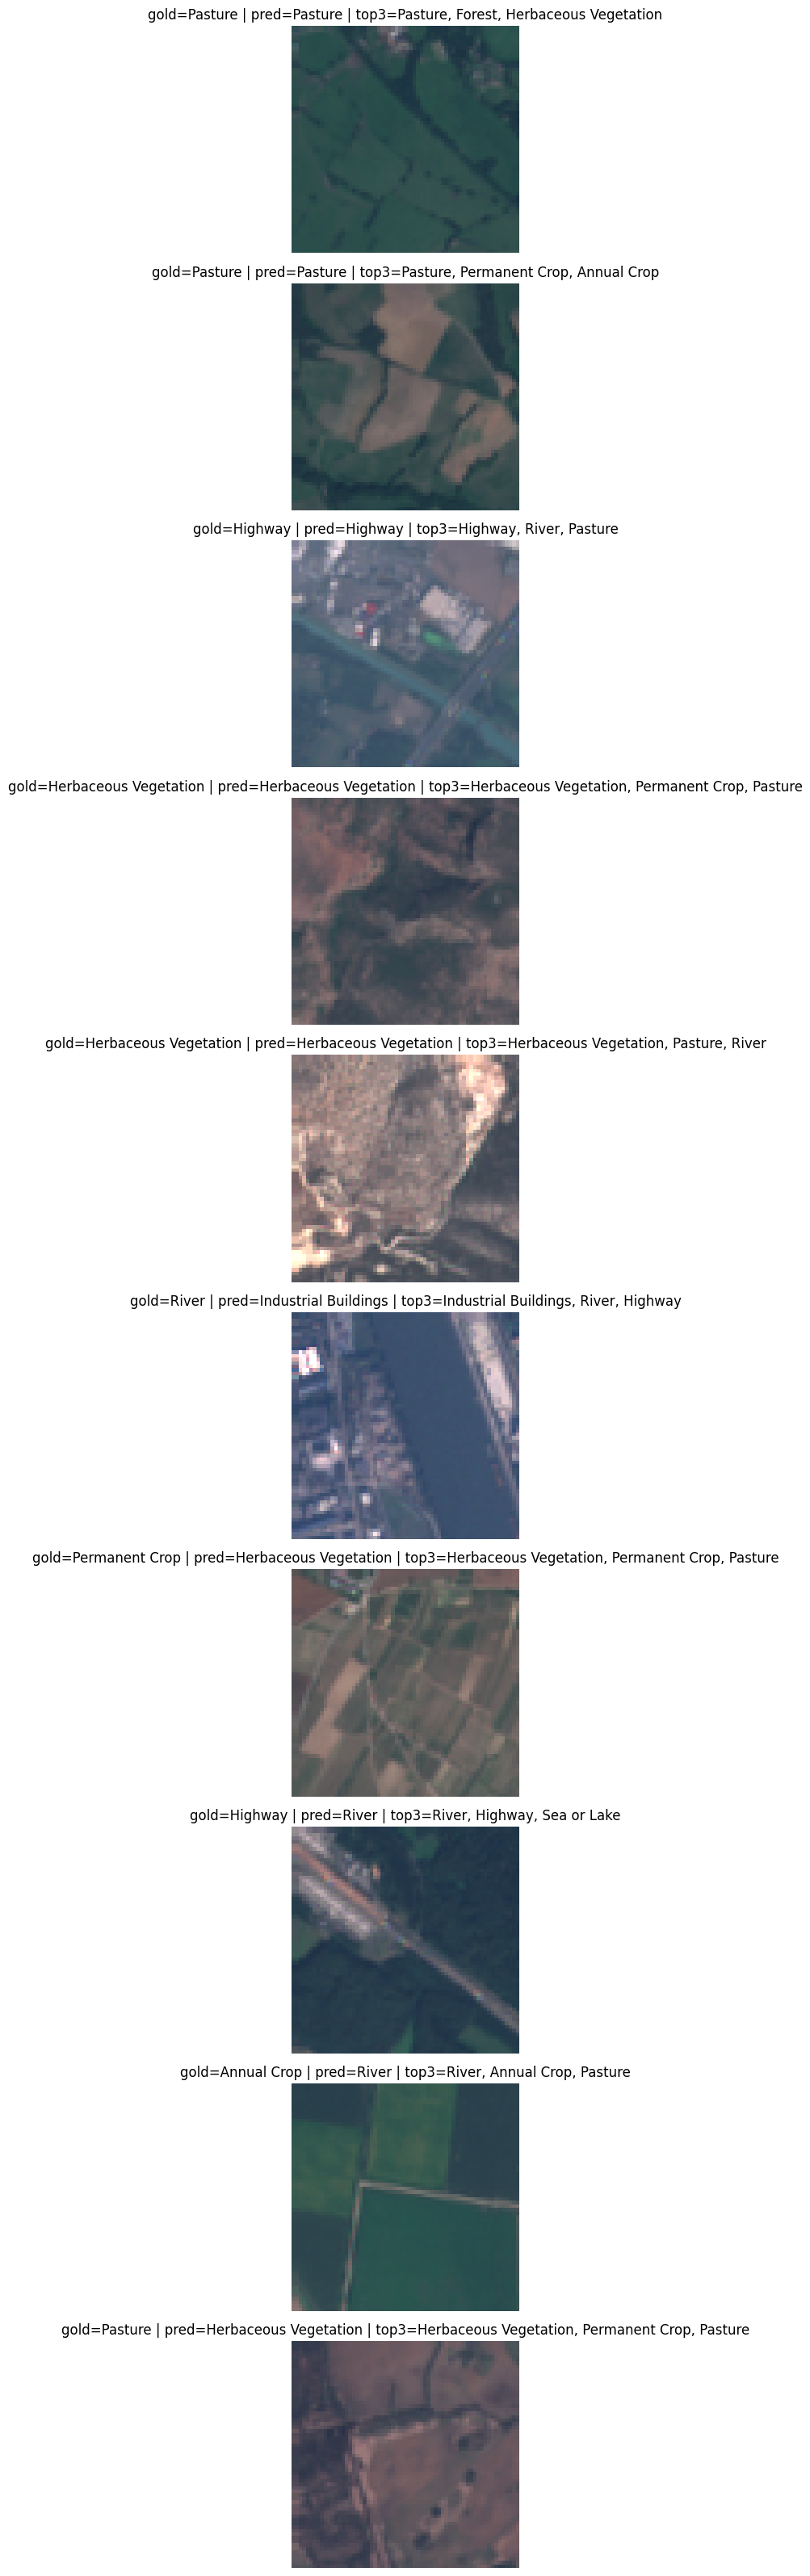

saved runs/figures/clip_qualitative_examples.png
Incorrect examples:
  gold=River pred=Industrial Buildings top3=['Industrial Buildings', 'River', 'Highway']
  gold=Permanent Crop pred=Herbaceous Vegetation top3=['Herbaceous Vegetation', 'Permanent Crop', 'Pasture']
  gold=Highway pred=River top3=['River', 'Highway', 'Sea or Lake']
  gold=Annual Crop pred=River top3=['River', 'Annual Crop', 'Pasture']
  gold=Pasture pred=Herbaceous Vegetation top3=['Herbaceous Vegetation', 'Permanent Crop', 'Pasture']


In [17]:
num_correct, num_incorrect = 5, 5
ckpt_path = RUNS_DIR / 'clip_eurosat' / 'best.pt'

with open('configs/clip_eurosat.yaml') as f:
    cfg = yaml.safe_load(f)
vit_cfg = cfg['vit']

ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
vit = ViT(**vit_cfg).to(DEVICE)
text_encoder = FrozenTextEncoder(cfg['text_encoder']['model_name']).to(DEVICE)
heads = ProjectionHeads(vit_cfg['d_model'], text_encoder.embedding_dim, cfg['projection']['d_proj']).to(DEVICE)
vit.load_state_dict(ckpt['vit'])
heads.load_state_dict(ckpt['projection_heads'])
vit.eval(); heads.eval(); text_encoder.eval()

_, val_dl, _ = build_eurosat_loaders(img_size=vit_cfg['img_size'], batch_size=64, num_workers=2)
class_prompts = [f'a satellite image of {name}' for name in EUROSAT_CLASSES]

correct_rows, incorrect_rows = [], []
with torch.no_grad():
    text_embeds = text_encoder(class_prompts)
    _, class_proj = heads(torch.zeros(len(class_prompts), vit.d_model, device=DEVICE), text_embeds)
    for images, captions in val_dl:
        images = images.to(DEVICE)
        labels = torch.tensor([class_prompts.index(c) for c in captions], device=DEVICE)
        image_features = vit(images)
        image_proj, _ = heads(image_features, torch.zeros(1, text_embeds.shape[-1], device=DEVICE))
        sims = image_proj @ class_proj.T
        top3_scores, top3_idx = sims.topk(k=3, dim=-1)
        preds = top3_idx[:, 0]
        for i in range(images.shape[0]):
            row = {
                'image': images[i].cpu(),
                'gold': EUROSAT_CLASSES[labels[i].item()],
                'pred': EUROSAT_CLASSES[preds[i].item()],
                'top3': [EUROSAT_CLASSES[j] for j in top3_idx[i].tolist()],
                'top3_scores': [float(s) for s in top3_scores[i].tolist()],
            }
            if preds[i].item() == labels[i].item():
                if len(correct_rows) < num_correct:
                    correct_rows.append(row)
            elif len(incorrect_rows) < num_incorrect:
                incorrect_rows.append(row)
        if len(correct_rows) >= num_correct and len(incorrect_rows) >= num_incorrect:
            break

rows = correct_rows + incorrect_rows
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
fig, axes = plt.subplots(len(rows), 1, figsize=(7, 3.2 * len(rows)))
if len(rows) == 1:
    axes = [axes]
for ax, row in zip(axes, rows):
    img = (row['image'] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"gold={row['gold']} | pred={row['pred']} | top3={', '.join(row['top3'])}")
    ax.axis('off')
savefig('clip_qualitative_examples.png')

print('Incorrect examples:')
for row in incorrect_rows:
    print(f"  gold={row['gold']} pred={row['pred']} top3={row['top3']}")

## 4. RESISC Experiments

### Linear Probe vs LoRA vs Full Finetuning

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method linear_probe --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_linear_probe

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 8 --alpha 16 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_lora_rank8

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method full_ft --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_full_ft

### §4.1 LoRA parameter counts and §4.2 method comparison

total params: 10,995,840
trainable params: 258,048
ratio: 0.023468
         method  test_acc  trainable_params  peak_mem_gb  wall_clock_min
0  linear_probe  0.371429             17325     0.233667        1.371692
1       lora_r8  0.423333            275373     1.120707        3.176776
2       full_ft  0.623651          10755117     1.625343        3.532173


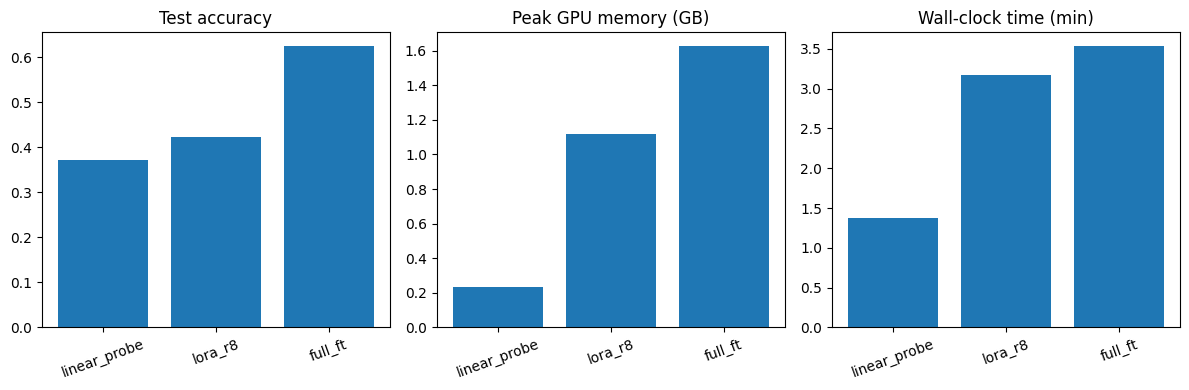

saved runs/figures/resisc_method_compare.png


In [18]:
with open('configs/clip_eurosat.yaml') as f:
    cfg = yaml.safe_load(f)
vit = ViT(**cfg['vit'])
apply_lora_to_attention(vit, rank=8, alpha=16.0)
total = sum(p.numel() for p in vit.parameters())
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'total params: {total:,}')
print(f'trainable params: {trainable:,}')
print(f'ratio: {trainable / total:.6f}')

runs = {
    'linear_probe': RUNS_DIR / 'resisc_linear_probe' / 'metrics.json',
    'lora_r8': RUNS_DIR / 'resisc_lora_rank8' / 'metrics.json',
    'full_ft': RUNS_DIR / 'resisc_full_ft' / 'metrics.json',
}
rows = []
for label, path in runs.items():
    m = read_json(path)
    rows.append(
        {
            'method': label,
            'test_acc': m['final_test_acc'],
            'trainable_params': m['trainable_params'],
            'peak_mem_gb': m['peak_memory_bytes'] / (1024 ** 3),
            'wall_clock_min': m['wall_clock_seconds'] / 60,
        }
    )
df = pd.DataFrame(rows)
print(df)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(df['method'], df['test_acc'])
axes[0].set_title('Test accuracy')
axes[1].bar(df['method'], df['peak_mem_gb'])
axes[1].set_title('Peak GPU memory (GB)')
axes[2].bar(df['method'], df['wall_clock_min'])
axes[2].set_title('Wall-clock time (min)')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
savefig('resisc_method_compare.png')

### LoRA Rank Sweep

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 1 --alpha 2 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_1
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 2 --alpha 4 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_2
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 4 --alpha 8 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_4
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 8 --alpha 16 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_8
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 16 --alpha 32 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_16
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 32 --alpha 64 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_32
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 64 --alpha 128 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_64

### §4.2 LoRA rank sweep plot

   rank  test_acc
0     1  0.336667
1     2  0.359841
2     4  0.381429
3     8  0.429683
4    16  0.452381
5    32  0.482063
6    64  0.521587


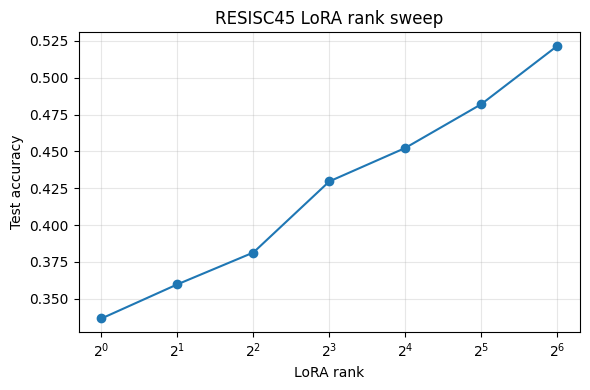

saved runs/figures/resisc_lora_rank_sweep.png


In [20]:
rows = []
for rank in [1, 2, 4, 8, 16, 32, 64]:
    m = read_json(RUNS_DIR / 'resisc_rank_sweep' / f'rank_{rank}' / 'metrics.json')
    rows.append({'rank': rank, 'test_acc': m['final_test_acc']})
df = pd.DataFrame(rows)
print(df)

plt.figure(figsize=(6, 4))
plt.plot(df['rank'], df['test_acc'], marker='o')
plt.xscale('log', base=2)
plt.xlabel('LoRA rank')
plt.ylabel('Test accuracy')
plt.title('RESISC45 LoRA rank sweep')
plt.grid(True, alpha=0.3)
savefig('resisc_lora_rank_sweep.png')

## 5. VLM Training

In [ ]:
!python scripts/download_clevr.py

### Injection Comparison (2000 steps)

In [ ]:
!(mkdir -p runs/vlm_all_patches_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_all_patches_image_bidir_A | tee runs/vlm_all_patches_image_bidir_A/train.log)

In [ ]:
!(mkdir -p runs/vlm_cls_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection cls --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_cls_image_bidir_A | tee runs/vlm_cls_image_bidir_A/train.log)

In [ ]:
!(mkdir -p runs/vlm_interleaved_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection interleaved --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_interleaved_image_bidir_A | tee runs/vlm_interleaved_image_bidir_A/train.log)

### §5.4 Injection comparison table/plot

In [ ]:
runs = [
    RUNS_DIR / 'vlm_cls_image_bidir_A',
    RUNS_DIR / 'vlm_all_patches_image_bidir_A',
    RUNS_DIR / 'vlm_interleaved_image_bidir_A',
]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['injection', 'num_visual_tokens', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(7, 4))
plt.bar(df['injection'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM injection comparison')
savefig('vlm_injection_compare.png')

### Masking Comparison (500 steps, all_patches)

In [ ]:
!(mkdir -p runs/vlm_all_patches_causal_A_500 && python scripts/train_vlm.py --config configs/vlm_clevr_500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode causal --freeze-config A --output-dir runs/vlm_all_patches_causal_A_500 | tee runs/vlm_all_patches_causal_A_500/train.log)
!(mkdir -p runs/vlm_all_patches_image_bidir_A_500 && python scripts/train_vlm.py --config configs/vlm_clevr_500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_all_patches_image_bidir_A_500 | tee runs/vlm_all_patches_image_bidir_A_500/train.log)

### §5.5 Attention mask diagrams and masking comparison

In [ ]:
n_visual, n_text = 4, 3
seq_len = n_visual + n_text
dtype = torch.float32
causal = build_causal_mask(seq_len, device='cpu', dtype=dtype)[0, 0].numpy()
bidir = build_image_bidir_mask(n_visual, n_text, device='cpu', dtype=dtype)[0, 0].numpy()
labels = [f'v{i+1}' for i in range(n_visual)] + [f't{i+1}' for i in range(n_text)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in [
    (axes[0], (causal >= 0).astype(float), 'M1: fully causal'),
    (axes[1], (bidir >= 0).astype(float), 'M2: image bidirectional'),
]:
    ax.imshow(mat, cmap='Greys', vmin=0, vmax=1)
    ax.set_xticks(range(seq_len), labels, rotation=45)
    ax.set_yticks(range(seq_len), labels)
    ax.set_title(title)
savefig('vlm_attention_masks.png')

runs = [
    RUNS_DIR / 'vlm_all_patches_causal_A_500',
    RUNS_DIR / 'vlm_all_patches_image_bidir_A_500',
]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['mask_mode', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(6, 4))
plt.bar(df['mask_mode'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM masking comparison (500 steps)')
savefig('vlm_masking_compare.png')

### Freezing Comparison (1500 steps, all_patches + image_bidir)

In [ ]:
!(mkdir -p runs/vlm_freeze_A && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_freeze_A | tee runs/vlm_freeze_A/train.log)
!(mkdir -p runs/vlm_freeze_B && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config B --output-dir runs/vlm_freeze_B | tee runs/vlm_freeze_B/train.log)
!(mkdir -p runs/vlm_freeze_C && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config C --output-dir runs/vlm_freeze_C | tee runs/vlm_freeze_C/train.log)
!(mkdir -p runs/vlm_freeze_D && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config D --output-dir runs/vlm_freeze_D | tee runs/vlm_freeze_D/train.log)

### §5.6 Freezing comparison table/plot

In [ ]:
runs = [RUNS_DIR / f'vlm_freeze_{c}' for c in ['A', 'B', 'C', 'D']]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['freeze_config', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(7, 4))
plt.bar(df['freeze_config'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM freezing comparison (1500 steps)')
savefig('vlm_freezing_compare.png')

### §5.7 Qualitative Evaluation

Run this after implementing `scripts/eval_vlm.py`. Update the checkpoint path if your best run differs.

In [ ]:
!python scripts/eval_vlm.py --checkpoint runs/vlm_all_patches_image_bidir_A/best.pt --num-examples 10 --save-images --output-dir runs/vlm_qualitative

In [ ]:
examples_path = RUNS_DIR / 'vlm_qualitative' / 'examples.jsonl'
assert examples_path.exists(), f'missing {examples_path} — implement scripts/eval_vlm.py first'

rows = [json.loads(line) for line in open(examples_path)]
fig, axes = plt.subplots(len(rows), 1, figsize=(8, 3.2 * len(rows)))
if len(rows) == 1:
    axes = [axes]
for ax, row in zip(axes, rows):
    img_path = row.get('saved_image')
    if img_path and Path(img_path).exists():
        ax.imshow(Image.open(img_path))
    ax.set_title(
        f"Q: {row['question']}\nGold: {row['gold']} | Pred: {row['prediction']} | correct={row['correct']}"
    )
    ax.axis('off')
savefig('vlm_qualitative_examples.png')

## 6. Positional Encodings and RoPE

In [ ]:
!python -m pytest -k test_rope -q

### §6.1 Verify RoPE preserves vector norms

In [ ]:
from basics.rope import RoPE1D, RoPE2D

torch.manual_seed(SEED)
head_dim, max_seq, grid = 64, 32, 12
x1d = torch.randn(4, 6, 16, head_dim)
pos = torch.arange(16)
out1d = RoPE1D(head_dim, max_seq)(x1d, pos)
diff1d = (x1d.norm(dim=-1) - out1d.norm(dim=-1)).abs()
print('RoPE1D max |Δnorm| =', diff1d.max().item())

x2d = torch.randn(2, 4, 20, head_dim)
x_coords = torch.randint(0, grid, (20,))
y_coords = torch.randint(0, grid, (20,))
out2d = RoPE2D(head_dim, grid)(x2d, x_coords, y_coords)
diff2d = (x2d.norm(dim=-1) - out2d.norm(dim=-1)).abs()
print('RoPE2D max |Δnorm| =', diff2d.max().item())

### §6.1–6.2 CLIP with 1D and 2D RoPE

Section 3 already trains the learned-PE baseline at `runs/clip_eurosat`. Retrain with RoPE variants below (20 epochs each).

In [ ]:
!(mkdir -p runs/clip_eurosat_rope_1d && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc rope_1d --max-img-size 96 --eval-img-size 96 --output-dir runs/clip_eurosat_rope_1d | tee runs/clip_eurosat_rope_1d/train.log)
!(mkdir -p runs/clip_eurosat_rope_2d && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc rope_2d --max-img-size 96 --eval-img-size 96 --output-dir runs/clip_eurosat_rope_2d | tee runs/clip_eurosat_rope_2d/train.log)

### §6.1–6.2 Length extrapolation comparison (64 → 96 px)

In [ ]:
run_dirs = {
    'learned': RUNS_DIR / 'clip_eurosat',
    'rope_1d': RUNS_DIR / 'clip_eurosat_rope_1d',
    'rope_2d': RUNS_DIR / 'clip_eurosat_rope_2d',
}
rows = []
for label, run_dir in run_dirs.items():
    log_path = run_dir / 'train.log'
    assert log_path.exists(), f'missing {log_path}'
    summary = parse_clip_summary(log_path)
    summary['pos_encoding'] = summary.get('pos_encoding', label)
    rows.append(summary)

df = pd.DataFrame(rows)
cols = ['pos_encoding', 'best_val_zeroshot_acc', 'extrap_val_zeroshot_acc', 'eval_img_size']
print(df[cols])
df['val_drop'] = df['best_val_zeroshot_acc'] - df['extrap_val_zeroshot_acc']

x = np.arange(len(df))
width = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, df['best_val_zeroshot_acc'], width, label='64×64 val')
plt.bar(x + width / 2, df['extrap_val_zeroshot_acc'], width, label='96×96 val (extrap)')
plt.xticks(x, df['pos_encoding'])
plt.ylabel('Zero-shot accuracy')
plt.title('CLIP positional encoding: train vs extrapolated resolution')
plt.legend()
savefig('clip_posenc_extrapolation.png')